In [7]:
! pip install pandas numpy nltk scikit-learn tensorflow matplotlib seaborn

In [8]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

/home/allen/Documents/Capstone/Code/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/allen/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt to /home/allen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/allen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/allen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
import pandas as pd

# Load datasets
covid_df = pd.read_csv("/home/allen/Documents/Material/NLP/Project_NLP/Covid-19/Covid-19 Twitter Dataset (Apr-Jun 2021).csv")  # replace with your actual filename
demo_df = pd.read_csv("/home/allen/Documents/Material/NLP/Project_NLP/Demonatization/demonetization-tweets.csv")  # replace with your actual filename

# Basic info
print("COVID Dataset")
print(covid_df.shape)
print(covid_df.columns.tolist())
print(covid_df.head())

print("\nDemonetization Dataset")
print(demo_df.shape)
print(demo_df.columns.tolist())
print(demo_df.head())

COVID Dataset
(147475, 17)
['id', 'created_at', 'source', 'original_text', 'lang', 'favorite_count', 'retweet_count', 'original_author', 'hashtags', 'user_mentions', 'place', 'clean_tweet', 'compound', 'neg', 'neu', 'pos', 'sentiment']
                    id  created_at  \
0  1386694264550270000  2021-04-26   
1  1386694260213170000  2021-04-26   
2  1386694256413320000  2021-04-26   
3  1386694252017630000  2021-04-26   
4  1386694248284700000  2021-04-26   

                                              source  \
0  <a href="http://twitter.com/download/android" ...   
1  <a href="http://twitter.com/download/iphone" r...   
2  <a href="http://twitter.com/download/iphone" r...   
3  <a href="https://mobile.twitter.com" rel="nofo...   
4  <a href="https://mobile.twitter.com" rel="nofo...   

                                       original_text lang  favorite_count  \
0  RT @VP: The U.S. is working closely with the I...   en             0.0   
1  RT @JackPosobiec: Flip-Flop Fauci admits 

In [10]:
print(covid_df['original_text'].isnull().sum())
print(demo_df['text'].isnull().sum())

0
0


In [11]:
print(covid_df['lang'].value_counts())

lang
en    147474
Name: count, dtype: int64


In [12]:
# Keep only English tweets
covid_df = covid_df[covid_df['lang'] == 'en']

# Keep only the raw text column we need
covid_df = covid_df[['id', 'original_text']].rename(columns={'original_text': 'raw_text'})

# Demonetization: keep only what we need
demo_df = demo_df[['id', 'text']].rename(columns={'text': 'raw_text'})

print(covid_df.shape)
print(demo_df.shape)

(147474, 2)
(14940, 2)


In [13]:
import re

def basic_clean(text):
    text = str(text)
    text = re.sub(r'^RT\s@\w+:', '', text)      # remove leading "RT @user:"
    text = re.sub(r'@\w+', '', text)             # remove @mentions
    text = re.sub(r'http\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'#', '', text)                 # remove hashtag symbol (keep the word)
    text = re.sub(r'[^A-Za-z\s]', '', text)       # remove numbers, punctuation, emojis
    text = text.strip()
    return text

covid_df['raw_text'] = covid_df['raw_text'].apply(basic_clean)
demo_df['raw_text'] = demo_df['raw_text'].apply(basic_clean)

print(covid_df['raw_text'].head())
print(demo_df['raw_text'].head())

0    The US is working closely with the Indian gove...
1    FlipFlop Fauci admits outdoor COVID transmissi...
2    Hi Twitter Im Tim Manning the White House COVI...
3    Praying for India as the country battles the w...
4    Rapid Investment in Nursing to Strengthen the ...
Name: raw_text, dtype: object
0    Critical question Was PayTM informed about Dem...
1    Did you vote on Demonetization on Modi survey app
2    Former FinSec RBI Dy Governor CBDT Chair  Harv...
3    Gurugram Haryana Post office employees provide...
4    Reddy Wedding  cartoon demonetization ReddyWed...
Name: raw_text, dtype: object


In [14]:
print((covid_df['raw_text'].str.strip() == '').sum())
print((demo_df['raw_text'].str.strip() == '').sum())

675
27


In [15]:
covid_df = covid_df[covid_df['raw_text'].str.strip() != '']
demo_df = demo_df[demo_df['raw_text'].str.strip() != '']

print(covid_df.shape)
print(demo_df.shape)

(146799, 2)
(14913, 2)


In [16]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess(text):
    text = text.lower()                          # case conversion
    tokens = word_tokenize(text)                  # tokenization
    tokens = [w for w in tokens if w.isalpha()]    # keep only words (extra punctuation safety)
    tokens = [w for w in tokens if w not in stop_words]  # stop word removal
    tokens = [stemmer.stem(w) for w in tokens]     # stemming
    return " ".join(tokens)

covid_df['clean_text'] = covid_df['raw_text'].apply(preprocess)
demo_df['clean_text'] = demo_df['raw_text'].apply(preprocess)

print(covid_df[['raw_text', 'clean_text']].head())
print(demo_df[['raw_text', 'clean_text']].head())

                                            raw_text  \
0  The US is working closely with the Indian gove...   
1  FlipFlop Fauci admits outdoor COVID transmissi...   
2  Hi Twitter Im Tim Manning the White House COVI...   
3  Praying for India as the country battles the w...   
4  Rapid Investment in Nursing to Strengthen the ...   

                                          clean_text  
0  us work close indian govern rapidli deploy add...  
1   flipflop fauci admit outdoor covid transmiss low  
2  hi twitter im tim man white hous covid suppli ...  
3  pray india countri battl worst covid surg worl...  
4  rapid invest nurs strengthen global covid respons  
                                            raw_text  \
0  Critical question Was PayTM informed about Dem...   
1  Did you vote on Demonetization on Modi survey app   
2  Former FinSec RBI Dy Governor CBDT Chair  Harv...   
3  Gurugram Haryana Post office employees provide...   
4  Reddy Wedding  cartoon demonetization ReddyWed... 

In [17]:
print((covid_df['clean_text'].str.strip() == '').sum())
print((demo_df['clean_text'].str.strip() == '').sum())

35
1


In [18]:
covid_df = covid_df[covid_df['clean_text'].str.strip() != '']
demo_df = demo_df[demo_df['clean_text'].str.strip() != '']

print(covid_df.shape)
print(demo_df.shape)

(146764, 3)
(14912, 3)


In [19]:
print((covid_df['clean_text'].str.strip() == '').sum())
print((demo_df['clean_text'].str.strip() == '').sum())

0
0


In [20]:
import nltk
nltk.download('vader_lexicon')

/home/allen/Documents/Capstone/Code/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/allen/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/allen/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [21]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']  # this is our Avg_R equivalent
    if score > 0.0:
        return 'positive'
    elif score < 0.0:
        return 'negative'
    else:
        return 'neutral'

covid_df['avg_r'] = covid_df['clean_text'].apply(lambda t: sia.polarity_scores(t)['compound'])
covid_df['sentiment_label'] = covid_df['clean_text'].apply(get_sentiment)

demo_df['avg_r'] = demo_df['clean_text'].apply(lambda t: sia.polarity_scores(t)['compound'])
demo_df['sentiment_label'] = demo_df['clean_text'].apply(get_sentiment)

In [22]:
print(covid_df['sentiment_label'].value_counts())
print(demo_df['sentiment_label'].value_counts())

sentiment_label
neutral     65921
positive    44586
negative    36257
Name: count, dtype: int64
sentiment_label
positive    5435
neutral     5393
negative    4084
Name: count, dtype: int64


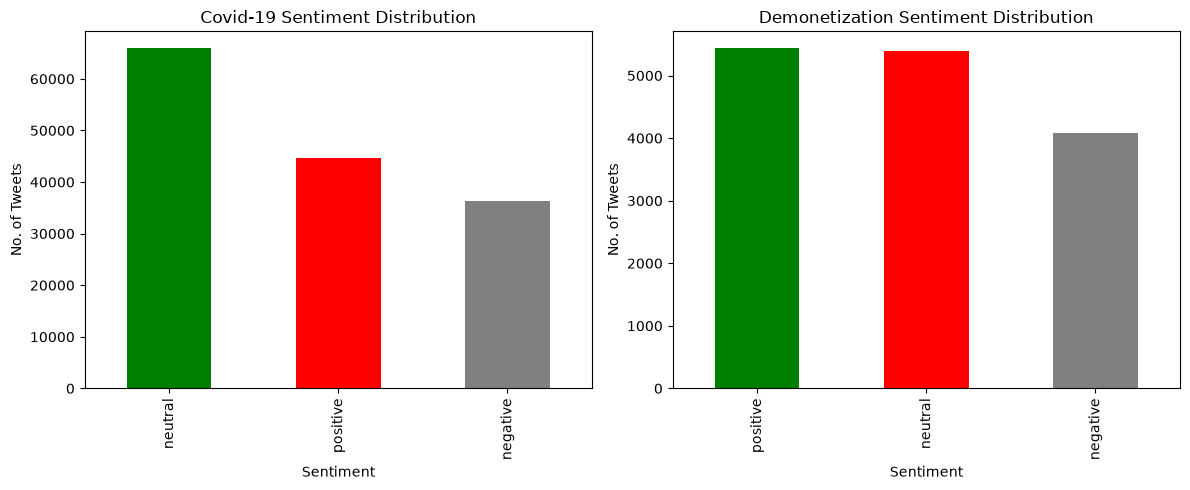

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

covid_df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[0], color=['green','red','gray'])
axes[0].set_title('Covid-19 Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('No. of Tweets')

demo_df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[1], color=['green','red','gray'])
axes[1].set_title('Demonetization Sentiment Distribution')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('No. of Tweets')

plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Covid-19
tfidf_covid = TfidfVectorizer(max_features=5000)
X_covid = tfidf_covid.fit_transform(covid_df['clean_text'])
y_covid = covid_df['sentiment_label']

# Demonetization
tfidf_demo = TfidfVectorizer(max_features=5000)
X_demo = tfidf_demo.fit_transform(demo_df['clean_text'])
y_demo = demo_df['sentiment_label']

print(X_covid.shape, y_covid.shape)
print(X_demo.shape, y_demo.shape)

(146764, 5000) (146764,)
(14912, 5000) (14912,)


In [25]:
from sklearn.model_selection import train_test_split

# Covid
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_covid, y_covid, test_size=0.2, stratify=y_covid, random_state=42
)

# Demonetization
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_demo, y_demo, test_size=0.2, stratify=y_demo, random_state=42
)

print(Xc_train.shape, Xc_test.shape)
print(Xd_train.shape, Xd_test.shape)

(117411, 5000) (29353, 5000)
(11929, 5000) (2983, 5000)


In [26]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm_covid = LinearSVC(class_weight='balanced', max_iter=2000)
svm_covid.fit(Xc_train, yc_train)
yc_pred_svm = svm_covid.predict(Xc_test)

svm_demo = LinearSVC(class_weight='balanced', max_iter=2000)
svm_demo.fit(Xd_train, yd_train)
yd_pred_svm = svm_demo.predict(Xd_test)

def evaluate(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{label} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

evaluate(yc_test, yc_pred_svm, "SVM - Covid")
evaluate(yd_test, yd_pred_svm, "SVM - Demonetization")

SVM - Covid -> Accuracy: 0.9686, Precision: 0.9685, Recall: 0.9686, F1: 0.9684
SVM - Demonetization -> Accuracy: 0.9601, Precision: 0.9604, Recall: 0.9601, F1: 0.9600


In [27]:
from sklearn.naive_bayes import MultinomialNB

nb_covid = MultinomialNB()
nb_covid.fit(Xc_train, yc_train)
yc_pred_nb = nb_covid.predict(Xc_test)

nb_demo = MultinomialNB()
nb_demo.fit(Xd_train, yd_train)
yd_pred_nb = nb_demo.predict(Xd_test)

evaluate(yc_test, yc_pred_nb, "NB - Covid")
evaluate(yd_test, yd_pred_nb, "NB - Demonetization")

NB - Covid -> Accuracy: 0.8818, Precision: 0.8812, Recall: 0.8818, F1: 0.8810
NB - Demonetization -> Accuracy: 0.9051, Precision: 0.9058, Recall: 0.9051, F1: 0.9051


In [28]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Covid
tokenizer_covid = Tokenizer(num_words=5000)
tokenizer_covid.fit_on_texts(covid_df['clean_text'])
sequences_covid = tokenizer_covid.texts_to_sequences(covid_df['clean_text'])
X_covid_rnn = pad_sequences(sequences_covid, maxlen=50)

# Demonetization
tokenizer_demo = Tokenizer(num_words=5000)
tokenizer_demo.fit_on_texts(demo_df['clean_text'])
sequences_demo = tokenizer_demo.texts_to_sequences(demo_df['clean_text'])
X_demo_rnn = pad_sequences(sequences_demo, maxlen=50)

print(X_covid_rnn.shape, X_demo_rnn.shape)

I0000 00:00:1790409485.438107    5068 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790409485.836189    5068 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790409487.739826    5068 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(146764, 50) (14912, 50)


In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_covid_rnn = le.fit_transform(covid_df['sentiment_label'])   # 0,1,2
y_demo_rnn = le.fit_transform(demo_df['sentiment_label'])

print(le.classes_)  # confirms label order, e.g. ['negative' 'neutral' 'positive']

['negative' 'neutral' 'positive']


In [30]:
Xc_train_rnn, Xc_test_rnn, yc_train_rnn, yc_test_rnn = train_test_split(
    X_covid_rnn, y_covid_rnn, test_size=0.2, stratify=y_covid_rnn, random_state=42
)

Xd_train_rnn, Xd_test_rnn, yd_train_rnn, yd_test_rnn = train_test_split(
    X_demo_rnn, y_demo_rnn, test_size=0.2, stratify=y_demo_rnn, random_state=42
)

print(Xc_train_rnn.shape, Xd_train_rnn.shape)

(117411, 50) (11929, 50)


In [31]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot (since we have 3 classes)
yc_train_cat = to_categorical(yc_train_rnn, num_classes=3)
yc_test_cat = to_categorical(yc_test_rnn, num_classes=3)

yd_train_cat = to_categorical(yd_train_rnn, num_classes=3)
yd_test_cat = to_categorical(yd_test_rnn, num_classes=3)

def build_rnn():
    model = Sequential([
        Embedding(input_dim=5000, output_dim=64, input_length=50),
        SimpleRNN(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Covid RNN
rnn_covid = build_rnn()
rnn_covid.fit(Xc_train_rnn, yc_train_cat, epochs=5, batch_size=128, validation_split=0.1)

# Demonetization RNN
rnn_demo = build_rnn()
rnn_demo.fit(Xd_train_rnn, yd_train_cat, epochs=5, batch_size=128, validation_split=0.1)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

rnn_covid = build_rnn()
rnn_covid.fit(Xc_train_rnn, yc_train_cat, epochs=10, batch_size=128, validation_split=0.1, callbacks=[early_stop])

rnn_demo = build_rnn()
rnn_demo.fit(Xd_train_rnn, yd_train_cat, epochs=10, batch_size=128, validation_split=0.1, callbacks=[early_stop])

/home/allen/Documents/Capstone/Code/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1790409492.662314    5068 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2142 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


I0000 00:00:1790409494.256882    5757 service.cc:153] XLA service 0x71daf8032410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790409494.256919    5757 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790409494.307160    5757 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790409494.625024    5757 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1790409494.652402    5757 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1768_grad_1970_const_0__.26.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790409494.652513    5757 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2536__.29
I0000 00:00:1790409494.685933    5757 dot_search_space.cc:240] All configs were filtered out

 25/826 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4506 - loss: 1.0569

I0000 00:00:1790409500.988184    5757 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

826/826 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8860 - loss: 0.3109 - val_accuracy: 0.9572 - val_loss: 0.1651
Epoch 2/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9637 - loss: 0.1376 - val_accuracy: 0.9633 - val_loss: 0.1476
Epoch 3/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9669 - loss: 0.1206 - val_accuracy: 0.9638 - val_loss: 0.1455
Epoch 4/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9731 - loss: 0.0931 - val_accuracy: 0.9633 - val_loss: 0.1584
Epoch 5/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9678 - loss: 0.1053 - val_accuracy: 0.9586 - val_loss: 0.1702
Epoch 1/10


I0000 00:00:1790409581.590898    5756 dot_merger.cc:481] Merging Dots in computation: sequential_3_1_simple_rnn_3_1_while_body_49677_grad_49879_const_0__.26.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790409581.590973    5756 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50445__.29


83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7762 - loss: 0.5545

I0000 00:00:1790409583.399728    5757 dot_merger.cc:481] Merging Dots in computation: sequential_3_1_simple_rnn_3_1_while_body_49677_grad_49879_const_0__.26.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790409583.399823    5757 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50445__.29


84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7773 - loss: 0.5519 - val_accuracy: 0.8642 - val_loss: 0.3336
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9495 - loss: 0.1489 - val_accuracy: 0.8994 - val_loss: 0.2634
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9924 - loss: 0.0333 - val_accuracy: 0.9053 - val_loss: 0.2898
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0091 - val_accuracy: 0.9044 - val_loss: 0.3130


In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_rnn(model, X_test, y_test_cat, label):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{label} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

evaluate_rnn(rnn_covid, Xc_test_rnn, yc_test_cat, "RNN - Covid")
evaluate_rnn(rnn_demo, Xd_test_rnn, yd_test_cat, "RNN - Demonetization")

918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
RNN - Covid -> Accuracy: 0.9641, Precision: 0.9639, Recall: 0.9641, F1: 0.9640
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
RNN - Demonetization -> Accuracy: 0.9024, Precision: 0.9032, Recall: 0.9024, F1: 0.9023


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

# SVM
svm_covid_metrics = get_metrics(yc_test, yc_pred_svm)
svm_demo_metrics = get_metrics(yd_test, yd_pred_svm)

# NB
nb_covid_metrics = get_metrics(yc_test, yc_pred_nb)
nb_demo_metrics = get_metrics(yd_test, yd_pred_nb)

# RNN
rnn_covid_pred = np.argmax(rnn_covid.predict(Xc_test_rnn), axis=1)
rnn_covid_true = np.argmax(yc_test_cat, axis=1)
rnn_covid_metrics = get_metrics(rnn_covid_true, rnn_covid_pred)

rnn_demo_pred = np.argmax(rnn_demo.predict(Xd_test_rnn), axis=1)
rnn_demo_true = np.argmax(yd_test_cat, axis=1)
rnn_demo_metrics = get_metrics(rnn_demo_true, rnn_demo_pred)

# Build results table directly from real variables
rows = []
for clf_name, covid_m, demo_m in [
    ('SVM', svm_covid_metrics, svm_demo_metrics),
    ('NB', nb_covid_metrics, nb_demo_metrics),
    ('RNN', rnn_covid_metrics, rnn_demo_metrics)
]:
    rows.append({'Classifier': clf_name, 'Dataset': 'Covid-19', **covid_m})
    rows.append({'Classifier': clf_name, 'Dataset': 'Demonetization', **demo_m})

results = pd.DataFrame(rows)
print(results)
results.to_csv('classification_results.csv', index=False)

918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
  Classifier         Dataset  Accuracy  Precision    Recall        F1
0        SVM        Covid-19  0.968623   0.968490  0.968623  0.968441
1        SVM  Demonetization  0.960107   0.960386  0.960107  0.960040
2         NB        Covid-19  0.881818   0.881164  0.881818  0.881022
3         NB  Demonetization  0.905129   0.905809  0.905129  0.905110
4        RNN        Covid-19  0.964126   0.963937  0.964126  0.963953
5        RNN  Demonetization  0.902447   0.903176  0.902447  0.902285


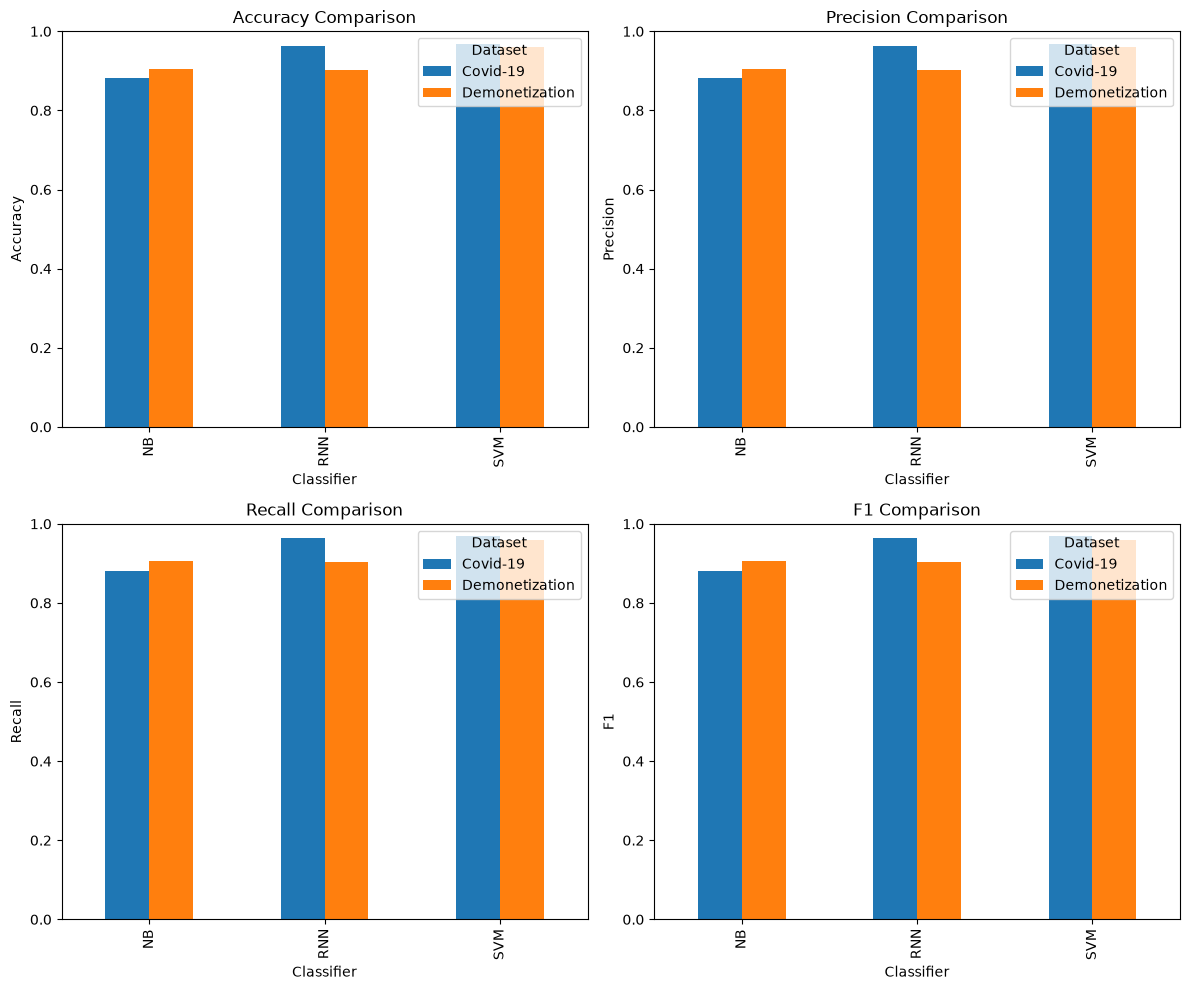

In [35]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    pivot = results.pivot(index='Classifier', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='Dataset')

plt.tight_layout()
plt.savefig('classifier_comparison.png')
plt.show()

In [36]:
from tensorflow.keras.layers import LSTM

def build_lstm():
    model = Sequential([
        Embedding(input_dim=5000, output_dim=64, input_length=50),
        LSTM(64, return_sequences=False),
        Dense(32, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Covid LSTM
lstm_covid = build_lstm()
lstm_covid.fit(Xc_train_rnn, yc_train_cat, epochs=10, batch_size=128, validation_split=0.1, callbacks=[early_stop])

# Demonetization LSTM
lstm_demo = build_lstm()
lstm_demo.fit(Xd_train_rnn, yd_train_cat, epochs=10, batch_size=128, validation_split=0.1, callbacks=[early_stop])

Epoch 1/10


/home/allen/Documents/Capstone/Code/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


826/826 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8994 - loss: 0.2786 - val_accuracy: 0.9653 - val_loss: 0.1426
Epoch 2/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9685 - loss: 0.1245 - val_accuracy: 0.9655 - val_loss: 0.1385
Epoch 3/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9722 - loss: 0.1040 - val_accuracy: 0.9710 - val_loss: 0.1082
Epoch 4/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9782 - loss: 0.0810 - val_accuracy: 0.9751 - val_loss: 0.1004
Epoch 5/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9817 - loss: 0.0674 - val_accuracy: 0.9772 - val_loss: 0.0991
Epoch 6/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9846 - loss: 0.0556 - val_accuracy: 0.9741 - val_loss: 0.1105
Epoch 7/10
826/826 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9862 - loss: 0.0468 - val_accuracy: 0.9753 - val_loss: 0.1155
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7137 - loss: 0.6461 - val_accuracy: 0.8776 - val_l

In [37]:
lstm_covid_pred = np.argmax(lstm_covid.predict(Xc_test_rnn), axis=1)
lstm_covid_true = np.argmax(yc_test_cat, axis=1)
lstm_covid_metrics = get_metrics(lstm_covid_true, lstm_covid_pred)

lstm_demo_pred = np.argmax(lstm_demo.predict(Xd_test_rnn), axis=1)
lstm_demo_true = np.argmax(yd_test_cat, axis=1)
lstm_demo_metrics = get_metrics(lstm_demo_true, lstm_demo_pred)

print("LSTM - Covid:", lstm_covid_metrics)
print("LSTM - Demonetization:", lstm_demo_metrics)

918/918 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
LSTM - Covid: {'Accuracy': 0.974755561612101, 'Precision': 0.9747392662178187, 'Recall': 0.974755561612101, 'F1': 0.9746668273859598}
LSTM - Demonetization: {'Accuracy': 0.9353000335232987, 'Precision': 0.9353055188630692, 'Recall': 0.9353000335232987, 'F1': 0.9352965463458907}


In [38]:
rows = []
for clf_name, covid_m, demo_m in [
    ('SVM', svm_covid_metrics, svm_demo_metrics),
    ('NB', nb_covid_metrics, nb_demo_metrics),
    ('RNN', rnn_covid_metrics, rnn_demo_metrics),
    ('LSTM', lstm_covid_metrics, lstm_demo_metrics)
]:
    rows.append({'Classifier': clf_name, 'Dataset': 'Covid-19', **covid_m})
    rows.append({'Classifier': clf_name, 'Dataset': 'Demonetization', **demo_m})

results = pd.DataFrame(rows)
print(results)
results.to_csv('classification_results.csv', index=False)

  Classifier         Dataset  Accuracy  Precision    Recall        F1
0        SVM        Covid-19  0.968623   0.968490  0.968623  0.968441
1        SVM  Demonetization  0.960107   0.960386  0.960107  0.960040
2         NB        Covid-19  0.881818   0.881164  0.881818  0.881022
3         NB  Demonetization  0.905129   0.905809  0.905129  0.905110
4        RNN        Covid-19  0.964126   0.963937  0.964126  0.963953
5        RNN  Demonetization  0.902447   0.903176  0.902447  0.902285
6       LSTM        Covid-19  0.974756   0.974739  0.974756  0.974667
7       LSTM  Demonetization  0.935300   0.935306  0.935300  0.935297


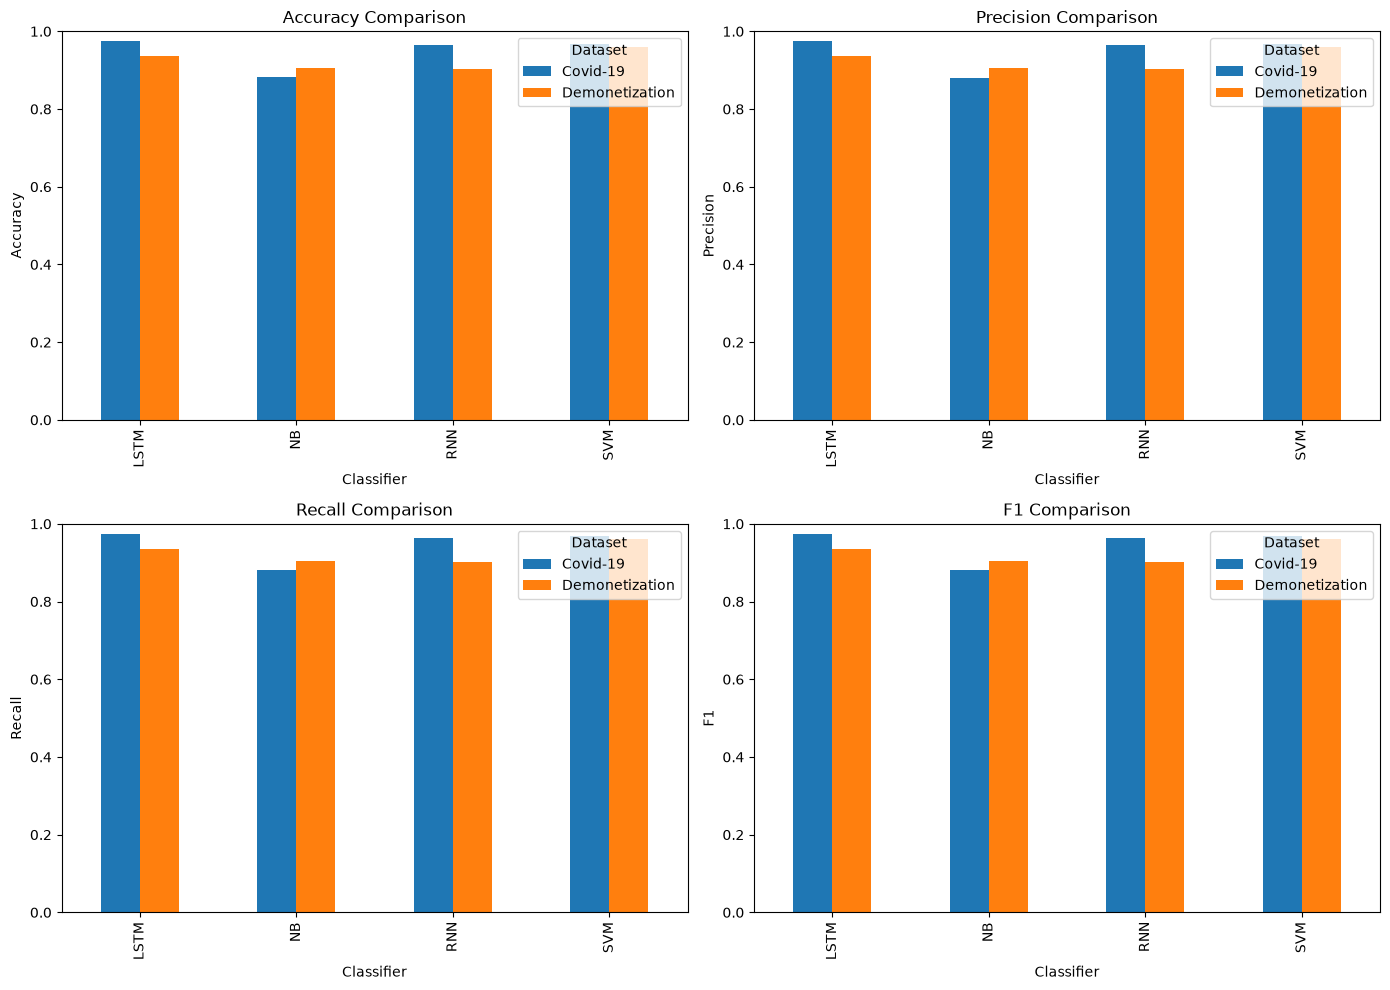

In [39]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    pivot = results.pivot(index='Classifier', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].legend(title='Dataset')

plt.tight_layout()
plt.savefig('classifier_comparison.png')
plt.show()